In [103]:
import os
import sys

# 実行環境の確認
if "google.colab" in sys.modules:
    print("✓ Running in Google Colab")
else:
    print("✗ Running locally (not Colab)")

print(f"Python version: {sys.version}")
print(f"Executable: {sys.executable}")
print(f"Working Directory: {os.getcwd()}")

✗ Running locally (not Colab)
Python version: 3.12.9 (main, Mar 17 2025, 21:01:58) [Clang 20.1.0 ]
Executable: /home/user/deep-learning-from-scratch-2/.venv/bin/python
Working Directory: /home/user/deep-learning-from-scratch-2/notebooks


In [104]:
# Colab で実行している場合、リポジトリをクローンする
#!git clone -b master https://github.com/AcademiXBase/deep-learning-from-scratch-2.git
#%cd deep-learning-from-scratch-2

In [105]:
sys.path.append('.')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd

# 自然言語と単語の分散表現

## 自然言語処理とは
自然言語処理 (Natural Language Processing: NLP) とは、私たちの言葉（自然言語）をコンピュータに理解させるための技術のことを指す。

### 自然言語の難しさ
プログラミング言語のような「固い言語」とは異なり、自然言語は意味の曖昧さや時代の変化を伴う「柔らかい言語」であることが特徴である。自然言語では、同じ言葉でも文脈によって意味が変わり、時代の経過とともに新しい言葉が生まれ、古い言葉の意味が変化することがある。  

### 本章の目的
本章の目的は、コンピュータに「単語の意味」を理解させることであり、ここではそれを実現するための手法として以下の 3 つを検討する  

1. シソーラス (類語辞書) による手法 (本章)  

2. カウントベースの手法 (本章)  

3. 推論ベースの手法 (word2vec) (次章以降)  


## 1. シソーラス (Thesaurus)
シソーラスとは基本的には類語辞書であり、「同じ意味の単語」や「意味の似た単語」が同じグループに分類される。  

### WordNet
WordNet は自然言語処理において最も有名なシソーラスである。WordNet を使うことで、単語間のつながりをグラフ構造として捉え、単語間の類似度を算出することが可能になる。  

### シソーラスの問題点
人の手で定義するシソーラスには、以下のような大きな欠点がある。  

* 時代の変化に対応するのが困難：  
    言語は常に変化し続けているため、新しい単語の追加や意味の変化をすべて手作業で追うのは困難  

* 人の手作業によるコストが高い：  
    膨大な単語間の関係を人間が定義し続けるには限界がある  

* 単語の細かなニュアンスを表現できない：  
    似た単語でも、微妙な使い分けやニュアンスの差を捉えきれない  

これらの問題を解決するために、大量のテキストデータ (コーパス) から自動的に単語の意味を抽出する「カウントベースの手法」へと進む。


## 2. カウントベースの手法
コーパス (corpus) とは、自然言語処理の研究やアプリケーションのために目的をもって収集された大量のテキストデータのことを指す。  

### コーパスの下準備
Python を用いて、テキストを単語IDのリストに変換する前処理を実装する。  

In [106]:
def preprocess(text):
    """
    テキストを小文字化し、記号を分離して単語 ID のリストに変換する
    """
    text = text.lower() # 小文字化
    text = text.replace('.', ' .') # ピリオドを分離
    words = text.split(' ') # 空白で分割

    word_to_id = {} # 単語から ID への辞書
    id_to_word = {} # ID から単語への辞書
    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word

    corpus = np.array([word_to_id[w] for w in words]) # 単語 ID のリストを作成

    return corpus, word_to_id, id_to_word

In [107]:
text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
print(f"ID to Word: {id_to_word}")
print(f"ID to Word: {word_to_id}")
print(f"Corpus: {corpus}")

ID to Word: {0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}
ID to Word: {'you': 0, 'say': 1, 'goodbye': 2, 'and': 3, 'i': 4, 'hello': 5, '.': 6}
Corpus: [0 1 2 3 4 1 5 6]


### 分布仮説 (Distributional Hypothesis)
分布仮説とは、「単語の意味は周囲の単語によって形成される」というアイデアのこと。この仮説に基づき、周囲の単語をカウントして集計したものを共起行列と呼ぶ。  

* コンテキスト：  
    注目する単語の周囲に存在する単語のこと  

* ウィンドウサイズ：  
    コンテキストとしてどこまで周囲の単語を含めるかの範囲のこと  
    サイズが 1 なら左右 1 単語ずつをコンテキストとする  

### 共起行列 (Co-occurrence Matrix)
分布仮説にもとづき、ある単語に対してその周囲にどの単語が何回出現したかを集計した行列を共起行列と呼ぶ。

In [108]:
def create_co_matrix(corpus, vocab_size, window_size=1):
    """
    コーパスから共起行列を作成する
    """
    corpus_size = len(corpus)
    co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int32)

    for idx, word_id in enumerate(corpus):
        for i in range(1, window_size + 1):
            left_idx = idx - i
            right_idx = idx + i

            # 左側の単語をカウント
            if left_idx >= 0:
                left_word_id = corpus[left_idx]
                co_matrix[word_id, left_word_id] += 1

            # 右側の単語をカウント
            if right_idx < corpus_size:
                right_word_id = corpus[right_idx]
                co_matrix[word_id, right_word_id] += 1
    return co_matrix

In [109]:
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)
print("Co-occurrence Matrix:")
print(C)

Co-occurrence Matrix:
[[0 1 0 0 0 0 0]
 [1 0 1 0 1 1 0]
 [0 1 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 1 0 1 0 0 0]
 [0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0]]


### 共起行列のヒートマップ可視化
共起行列を数値のまま見るのではなく、ヒートマップとして可視化することでどの単語同士が強く関連しているかを視覚的に確認する  

In [110]:
def plot_co_matrix(C, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(C, annot=True, cbar=False, xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.title("Co-occurrence Matrix Heatmap")
    plt.show()

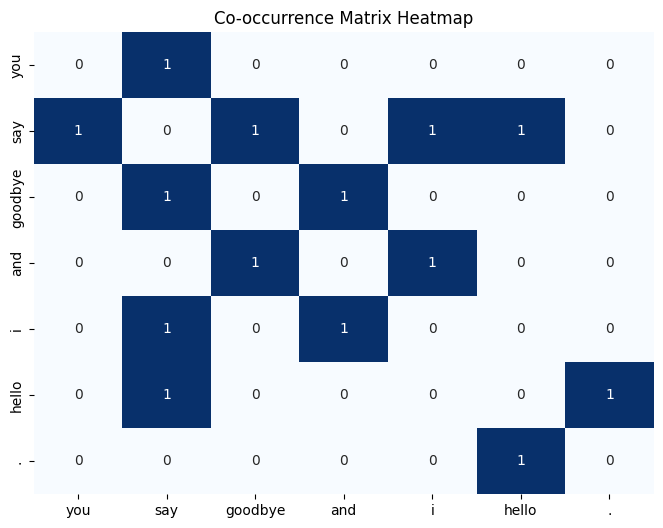

In [111]:
labels = [id_to_word[i] for i in range(len(id_to_word))]
plot_co_matrix(C, labels)

### ベクトル間の類似度
単語をベクトル化できたので、次はその「類似度」を計測する。一般的にコサイン類似度が用いられる。

In [112]:
def cos_similarity(x, y, eps=1e-8):
    # 0 除算を防ぐために eps を加算
    nx = x / (np.sqrt(np.sum(x ** 2)) + eps) # ベクトルの正規化
    ny = y / (np.sqrt(np.sum(y ** 2)) + eps)
    return np.dot(nx, ny)

In [113]:
# 「you」と「i」の類似度を比較してみる
c0 = C[word_to_id['you']]
c1 = C[word_to_id['i']]
print(f"Similarity (you, i): {cos_similarity(c0, c1):.4f}")

Similarity (you, i): 0.7071


### 類似単語のランキング表示
コサイン類似度を使い、ある単語に対して「意味の似た単語」を上位から順に表示する関数 `most_similar` を実装する  

In [114]:
def most_similar(query, word_to_id, id_to_word, word_matrix, top=5):
    """
    類似単語の検索
    """
    # 1. クエリを取り出す
    if query not in word_to_id:
        print(f'{query} is not found')
        return

    print(f'\n[query] {query}')
    query_id = word_to_id[query]
    query_vec = word_matrix[query_id]

    # 2. コサイン類似度の算出
    vocab_size = len(id_to_word)
    similarity = np.zeros(vocab_size)
    for i in range(vocab_size):
        similarity[i] = cos_similarity(word_matrix[i], query_vec)

    # 3. 類似度が高い順に出力
    count = 0
    # argsort() は配列の要素を小さい順に並べたインデックスを返す
    # -1 をかけることで降順 (大きい順) にする
    for i in (-1 * similarity).argsort():
        if id_to_word[i] == query:
            continue
        print(f' {id_to_word[i]}: {similarity[i]:.4f}')

        count += 1
        if count >= top:
            return

In [115]:
# "you" に似た単語を検索
# 現在は非常に小さなコーパスのため結果は限定的
most_similar('you', word_to_id, id_to_word, C, top=5)


[query] you
 goodbye: 0.7071
 hello: 0.7071
 i: 0.7071
 and: 0.0000
 say: 0.0000


## カウントベースの手法の改善
これまでの「共起行列」において、単語が共起した「回数」だけを数えている点は致命的な弱点をもたらす。例えば、「the」という単語は非常に高頻度に出現するため、どんな単語とも強い関連性 (大きな共起回数) を持つことになる。しかし、私たちが知りたいのは「the」との共起ではなく、意味的に重要な結びつきである。  

### 正の相互情報量 (PPMI)
これを解決するために、相互情報量 (Pointwise Mutual Information: PMI) という指標を導入する。  

$$\mathrm{PMI}(x,y) = \log_2 \frac{P(x,y)}{P(x)P(y)}$$

* $P(x)$ は単語 $x$ が出現する確率  

* $P(x,y)$ は単語 $x$ と $y$ が共起する確率  

PMI は単語が単独で出現する回数を考慮するため、高頻度な単語のノイズを抑えることができる。実用上は、対数の中が 0 になり値が $-\infty$ になるのを防ぐため、正の相互情報量 (Positive PMI: PPMI) を用いる。

$$\mathrm{PPMI}(x,y) = \max(0,\mathrm{PMI}(x,y))$$


### PPMI の実装

In [116]:
def ppmi(C, verbose=False, eps=1e-8):
    """
    PPMI (正の相互情報量) の作成
    """
    M = np.zeros_like(C, dtype=np.float32)
    N = np.sum(C) # コーパス全体の共起回数
    S = np.sum(C, axis=0) # 各単語の出現回数
    total = C.shape[0] * C.shape[1]
    cnt = 0

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            # 相互情報量の計算
            # log2(0) を防ぐために eps を加算
            pmi = np.log2(C[i, j] * N / (S[i]*S[j]) + eps)
            M[i, j] = max(0, pmi)

            if verbose:
                cnt += 1
                if cnt % (total // 100 + 1) == 0:
                    print(f'{(100*cnt/total):.1f}% done', end='\r')
    return M

In [ ]:
def ppmi(C, verbose=False, esp=1e-8):
  
    """
    Cは2次元の共起行列
    """
    M = np.zeros_like(C, dtype=np.float32) # 結果を格納する行列
    N = np.sum(C) # コーパスに含まれる全単語（ペア）の総数  
    S = np.sum(C, axis=0) # 各単語の出現回数の合計（ベクトル）
    total = C.shape[0] * C.shape[1]
    cnt = 0

In [117]:
# 共起行列を PPMI 行列に変換
W = ppmi(C)
print("PPMI Matrix:") # 有効桁 3 桁で表示
print(np.round(W, 3))

PPMI Matrix:
[[0.    1.807 0.    0.    0.    0.    0.   ]
 [1.807 0.    0.807 0.    0.807 0.807 0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.    1.807 0.    1.807 0.    0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.807 0.    0.    0.    0.    2.807]
 [0.    0.    0.    0.    0.    2.807 0.   ]]


### 共起行列 vs PPMI 行列の視覚的比較
「回数」ベースの共起行列と「相互情報量」ベースの PPMI 行列で、単語間の関係がどう変わったかをヒートマップで比較してみる

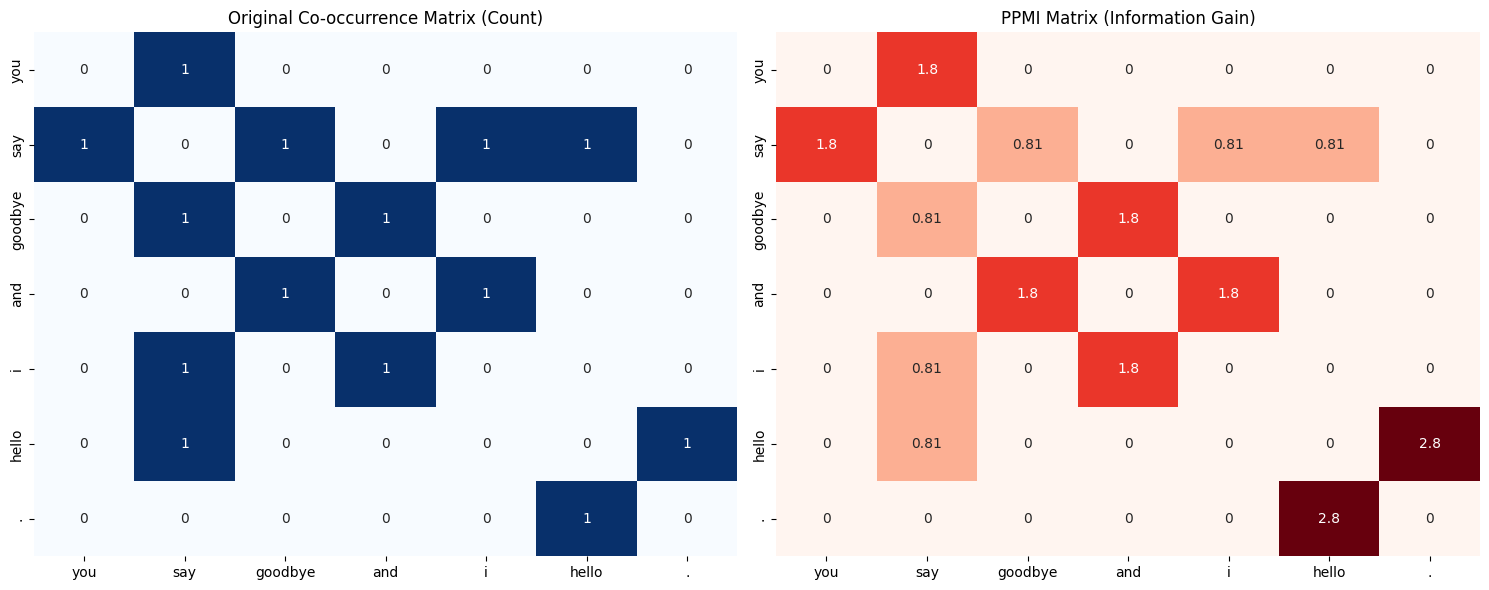

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 共起行列
sns.heatmap(C, annot=True, xticklabels=word_to_id.keys(), yticklabels=word_to_id.keys(), 
            cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title("Original Co-occurrence Matrix (Count)")

# PPMI 行列
sns.heatmap(W, annot=True, xticklabels=word_to_id.keys(), yticklabels=word_to_id.keys(), 
            cmap='Reds', ax=axes[1], cbar=False)
axes[1].set_title("PPMI Matrix (Information Gain)")

plt.tight_layout()
plt.show()

### 次元削減 (SVD)
PPMI 行列にはまだ「語彙数が増えると行列が巨大になり、かつそのほとんどが 0 (疎な行列) である」という問題がある。そこで、次元削減によって重要な情報を残したまま巨大なベクトルを小さな「密なベクトル」に圧縮する。本章では特異値分解 (Singular Value Decomposition: SVD) を用いる。  

### SVD の実装と可視化
NumPy の `linalg.svd` を使って単語ベクトルを 2 次元に圧縮し、グラフ上にプロットする。  

In [119]:
# SVD (特異値分解) による次元削減
U, S, V = np.linalg.svd(W)

print(f"元のベクトル (you): {W[word_to_id['you']]}")
print(f"SVD 後のベクトル (you): {U[word_to_id['you']]}")

元のベクトル (you): [0.        1.8073549 0.        0.        0.        0.        0.       ]
SVD 後のベクトル (you): [ 3.4094876e-01 -1.1102230e-16 -1.2051624e-01 -4.1633363e-16
 -9.3232495e-01 -1.1102230e-16 -2.4257469e-17]


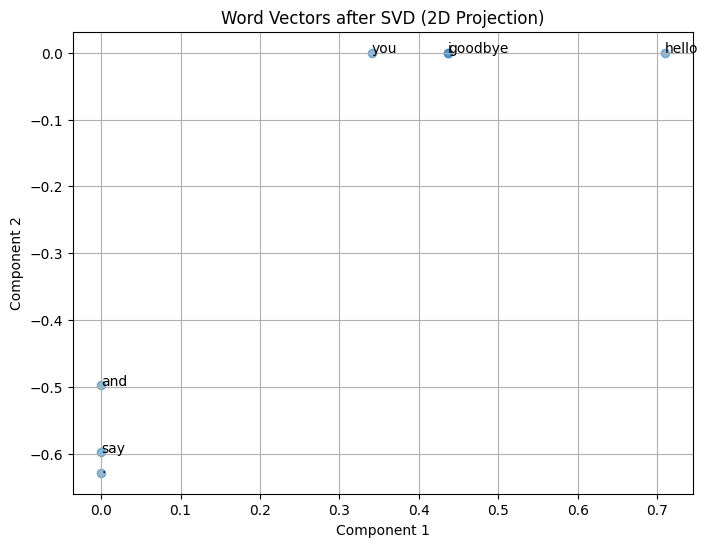

In [120]:
# 各単語を 2 次元のベクトルでプロット
plt.figure(figsize=(8, 6))
for word, word_id in word_to_id.items():
    plt.annotate(word, (U[word_id, 0], U[word_id, 1]))

plt.scatter(U[:,0], U[:,1], alpha=0.5)
plt.title("Word Vectors after SVD (2D Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

## PTB データセットでの評価
これまでは非常に小さなテキスト (「You say goodbye and I say hello.」) をコーパスとして扱ってきたが、これでは実用的な単語の分散表現は得られない。そこで、自然言語処理のベンチマークとしてよく利用される Penn Treebank (PTB) コーパスを使用する。  

PTB コーパスは、レアな単語を `<unk>` (unknown) に、数字を `N` に置き換えるなどの前処理が施されている。また、文の終わりに `<eos>` (end of sentence) という特殊文字が挿入される。  

In [121]:
# このセルを実行するには dataset/ptb.py が必要
try:
    from dataset import ptb

    # データの読み込み (初回は自動的にダウンロード)
    corpus, word_to_id, id_to_word = ptb.load_data('train')

    print(f'PTB コーパスサイズ: {len(corpus)}')
    print(f'corpus[:30]: {corpus[:30]}')
    print(f'id_to_word: {id_to_word}')
    print(f'id_to_word[1]: {id_to_word[1]}')
    print(f'word_to_id["car"]: {word_to_id["car"]}')

except ImportError:
    print("PTB dataset or sklearn not found. Skipping big dataset experiment.")

PTB dataset or sklearn not found. Skipping big dataset experiment.


### カウントベースの手法の評価
PTB データセットに対して、これまでに学んだ「共起行列の作成」「PPMIへの変換」「SVDによる次元削減」を一括して適用する。  

PTB のような大きな語彙数 (約 1 万語) に対して通常の SVD (`np.linalg.svd`) を行うと、計算に非常に時間がかかる。そのため、より高速な手法である Truncated SVD を使用する。これには `sklearn.utils.extmath.randomized_svd` を利用するのが便利。  

In [122]:
# ハイパーパラメータ
window_size = 2
wordvec_size = 100 # 最終的なベクトルの次元数

print('共起行列を作成中...')
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size, window_size)

print('PPMI 行列を計算中...')
W = ppmi(C, verbose=True)

print('SVD を計算中...')
# randomized_svd を使用して高速に次元削減
U, S, V = randomized_svd(W, n_components=wordvec_size, n_iter=5, random_state=42)

# 単語の分散表現 (100 次元の密なベクトル)
word_vecs = U[:, :wordvec_size]
print('SVD 完了')

共起行列を作成中...
PPMI 行列を計算中...
SVD を計算中...
SVD 完了


### 分散表現の性能確認
学習した分散表現を使って、「意味的に近い単語」が正しく抽出されるか確認してみる。  

In [123]:
# 学習した単語ベクトルを使って類似単語を検索
queries = ['you', 'year', 'car', 'toyota']
for query in queries:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)


[query] you
 and: 0.0000
 hello: 0.0000
 .: 0.0000
 i: -0.0000
 say: -0.0000
year is not found
car is not found
toyota is not found


### 特異値の減衰を可視化
SVD でなぜ次元を削減しても情報が保たれるのか、特異値 (Singular Values) をプロットして確認する。特異値は「その軸がどれだけ重要か」を表す。  

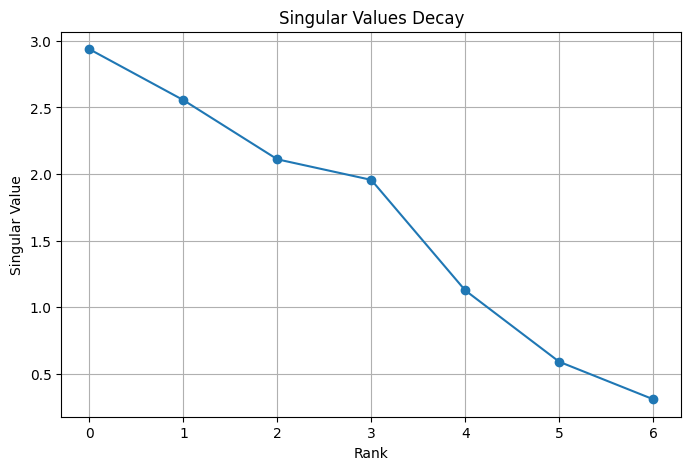

In [124]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(S)), S, marker='o')
plt.title("Singular Values Decay")
plt.xlabel("Rank")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

グラフを見ると、最初の数十個の成分にほとんどの情報が集中していることがわかる。これが次元削減の有効性を示す。  

## 本章のまとめ
本章では、コンピュータに単語の意味を理解させるための「シソーラス」と「カウントベースの手法」について学んだ。  

* シソーラス：  
    人の手によって単語のつながりを定義する (WordNet など)。人のコストが高く、時代の移り変わりに伴う言葉の変化に弱い  

* コーパス：  
    自然言語処理のために収集された大量のテキストデータ  

* 分布仮説：  
    「単語の意味は、周囲の単語によって形成される」という現代 NLP の基礎となる考え方  

* 共起行列：  
    分布仮説に基づき、コンテキスト内の単語頻度を集計してベクトル化する手法  
    PPMI (正の相互情報量)：単なる頻度ではなく、単語同士の「関連性の強さ」を適切に評価する指標  
    SVD (特異値分解)：巨大で疎な行列を、重要な情報を残したまま小さな密なベクトルに圧縮する手法  
    これらの手法を用いることで、単語の意味を多次元空間上の座標として表現する「単語の分散表現」を獲得することができた  